# Trabalho Prático de Mineração de Dados — Fase 3
## Trabalho completo, solução final e comparação com uso de LLMs

**Disciplina:** Mineração de Dados  
**Grupo:**

| Nome | Matrícula |
|---|---|
| Lucas Affonso Pires | 2023028420 |
| John Wesley Otaciano Costa | 2024014105 |
| Emmanuel Magalhães Figueiredo | 2024023821 |
| Bernardo Venancio Cunha Oliveira | 2023028684 |

**Dataset:** fifa_player_performance_market_value.csv  
**Tarefa de mineração:** Mineração de padrões frequentes e regras de associação  
**Data da entrega:** 09/05/2026

---

## Objetivo deste notebook

Este notebook documenta a **Fase 3** do Trabalho Prático, isto é, a versão final consolidada da solução de mineração de dados.

Nesta fase, o grupo:

1. corrigiu erros e limitações identificados na Fase 2;
2. consolidou a solução técnica efetivamente implementada;
3. executou a modelagem final;
4. avaliou criticamente os resultados;
5. comparou três elementos:
   - a solução sugerida pela LLM na condição **baseline**;
   - a solução sugerida pela LLM na condição **guiada por diretrizes de IA responsável**;
   - a solução final efetivamente implementada pelo grupo.

> **Importante:** este notebook integra e consolida as fases anteriores. As interações com LLMs e os links das conversas foram documentados na Fase 2. Aqui, mantemos a análise comparativa entre as trilhas, mas sem repetir os links completos.

# 0. Controle da entrega e rastreabilidade

| Item | Valor |
|---|---|
| Nome do dataset | fifa_player_performance_market_value.csv |
| Link público do dataset | https://www.kaggle.com/datasets/itszubi/fifa-player-performance-and-market-value |
| Número de linhas | 2800 |
| Número de colunas | 16 |
| Tarefa de mineração | Mineração de padrões frequentes e regras de associação para identificar perfis associados a valor de mercado e risco de transferência |
| Diretriz 1 de IA responsável | Justiça e Viés |
| Diretriz 2 de IA responsável | Explicabilidade |
| LLM usada na Fase 2 — baseline | Gemini Pro |
| LLM usada na Fase 2 — guiada | Gemini Pro / Gemini Fast |
| Notebook da Fase 2 | TPX_Fase2_GrupoXX.ipynb |

## Resumo das decisões herdadas da Fase 2

| Decisão | Origem | Foi mantida na Fase 3? | Justificativa |
|---|---|---|---|
| Usar FP-Growth como algoritmo principal e Apriori como comparação | Baseline e Guiada | Sim | Ambas as trilhas convergiram para essa escolha, confirmada empiricamente pela equivalência de resultados e pela vantagem de tempo do FP-Growth. |
| Discretização semântica das variáveis numéricas em categorias esportivas | Guiada (reforçada) + Baseline (sugerida) | Sim | Necessária tecnicamente para aplicar algoritmos de regras de associação; a abordagem semântica (Promessa, Auge, Veterano) melhora a interpretabilidade alinhada à diretriz de Explicabilidade. |
| Injeção de lógica factível para corrigir aleatoriedade absurda do dataset original | Grupo | Sim | O dataset original possuía inconsistências severas (ex: 8 partidas e 3.000 minutos jogados). A correção foi necessária para viabilizar padrões minimamente coerentes. |
| Suporte mínimo de 0.02 e confiança mínima de 0.60 | Baseline (0.02) + Guiada (0.05 rejeitado) | Sim (0.02) | Suporte 0.02 garante cobertura maior. O critério guiado de 0.05 foi testado mas considerado excessivamente restritivo para a base com 2800 registros. |
| Filtro de Lift >= 1.2 no pós-processamento | Guiada | Sim | Elimina regras triviais sem valor informativo. Confirmado como critério adequado pelos resultados. |
| Manter `nationality` com cautela analítica (não remover automaticamente) | Grupo (ajuste sobre sugestão guiada) | Sim | A remoção total empobreceria a análise; preferiu-se monitorar regras que a envolvam mas não tratá-la como preditor central de valor. |
| Remover `player_id` e `player_name` | Baseline + Guiada + Grupo | Sim | São identificadores únicos sem poder de generalização para padrões. |

> A rastreabilidade das decisões é parte importante da avaliação. Não basta apresentar o resultado final; é necessário explicar como o grupo chegou até ele.

In [1]:
# Configurações iniciais
import os
import time
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset.
DATA_PATH = "fifa_player_performance_market_value.csv"

# Tipo de tarefa do TP.
TASK_TYPE = "padroes_frequentes"

# Coluna-alvo: não aplicável para padrões frequentes.
TARGET_COLUMN = None

# Diretório para salvar artefatos.
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuração inicial carregada.")
print(f"TASK_TYPE = {TASK_TYPE}")
print(f"DATA_PATH = {DATA_PATH}")

Configuração inicial carregada.
TASK_TYPE = padroes_frequentes
DATA_PATH = fifa_player_performance_market_value.csv


# 1. Business Understanding

## 1.1 Problema de negócio e objetivo analítico

- **Contexto:** O mercado de transferências no futebol profissional envolve decisões de alto custo e alto risco financeiro. Clubes e departamentos de scouting precisam justificar contratações, renovações e investimentos com base em evidências objetivas, e não apenas em percepção subjetiva ou reputação de mercado.

- **Problema:** Identificar combinações recorrentes de características de jogadores — atributos esportivos, físicos, contratuais e demográficos — que estejam associadas a diferentes faixas de valor de mercado (`market_value_million_eur`) e a diferentes níveis de risco de transferência (`transfer_risk_level`).

- **Objetivo analítico:** Extrair regras de associação interpretáveis que expliquem como atributos de desempenho, idade, contrato e condição física se relacionam com valor de mercado e risco de transferência. O resultado final deve ser auditável e compreensível por analistas esportivos sem formação estatística avançada.

- **Usuários ou interessados:** Analistas de desempenho, departamentos de scouting, gestores esportivos e diretorias responsáveis por contratações.

- **Decisões apoiadas:** Priorização de perfis de jogadores para observação, identificação de atletas potencialmente supervalorizados ou subvalorizados e avaliação de fatores que aumentam ou reduzem o risco de uma negociação.

### Ajustes em relação à Fase 2

O objetivo central do trabalho foi mantido sem alterações substanciais. Os principais refinamentos após a Fase 2 foram:

- **Correção dos dados:** O dataset original apresentava inconsistências graves decorrentes de geração aleatória (ex: jogadores com 8 partidas e 3.000 minutos jogados). A Fase 2 identificou esse problema e a Fase 3 consolidou a injeção de lógica esportiva factível como etapa obrigatória da preparação.
- **Clareza sobre a natureza dos dados:** Reforçou-se nos textos que parte dos atributos foi enriquecida para fins educacionais, o que limita a extrapolação dos padrões para o mercado real.
- **Critério de relevância das regras:** O filtro Lift >= 1.2 e o tamanho máximo de 4 itens, sugeridos principalmente pela Trilha B, foram formalizados como parte do pipeline de avaliação.

## 1.2 Dataset, origem e características finais

### Identificação do dataset

- **Nome:** fifa_player_performance_market_value.csv
- **Fonte:** Kaggle — itszubi
- **Link público:** https://www.kaggle.com/datasets/itszubi/fifa-player-performance-and-market-value
- **Data de acesso:** 29/04/2026

### Características gerais

| Aspecto | Descrição |
|---|---|
| O que cada linha representa? | Um jogador de futebol profissional com seus atributos esportivos, físicos, contratuais e demográficos |
| O que cada coluna representa? | Atributos numéricos ou categóricos do jogador |
| Número de instâncias | 2800 |
| Número de atributos | 16 (originais); 14 após remoção de identificadores |
| Tipos principais de atributos | Numéricos discretos e contínuos; categóricos nominais e ordinais |
| Existe variável-alvo? | Sim: `transfer_risk_level` (risco) e `market_value_million_eur` (valor), ambas tratadas como consequentes nas regras |
| Existem atributos sensíveis ou identificadores? | Sim: `player_id` e `player_name` (identificadores removidos); `nationality` (atributo sensível, mantido com cautela analítica) |

### Dicionário de dados

| Coluna | Tipo | Descrição | Papel na análise | Observações |
|---|---|---|---|---|
| player_id | Numérico | Identificador único do jogador | ID — REMOVIDA | Sem valor para padrões gerais |
| player_name | Textual | Nome do jogador | ID — REMOVIDA | Sem valor para padrões gerais |
| age | Numérico discreto | Idade do jogador | Feature (discretizada) | Categorizada em Jovem, Auge, Veterano |
| nationality | Categórico | Nacionalidade | Feature (cautela) | Mantida; não usada como preditor central de valor |
| club | Categórico | Clube atual | Feature | Alta cardinalidade; prefixada para rastreabilidade |
| position | Categórico | Posição em campo | Feature | Importante para contextualizar desempenho |
| overall_rating | Numérico discreto | Avaliação geral atual | Feature (discretizada) | Categorizada em Baixo, Médio, Alto |
| potential_rating | Numérico discreto | Potencial estimado | Feature (discretizada) | Gerado com lógica baseada em idade + overall |
| matches_played | Numérico discreto | Partidas jogadas | Auxiliar (base para cálculo de taxas p90) | Usado para derivar goals_p90, assists_p90 e status_elenco |
| goals | Numérico discreto | Gols marcados | Auxiliar → goals_p90 | Recalculado com lógica por posição |
| assists | Numérico discreto | Assistências | Auxiliar → assists_p90 | Recalculado com lógica |
| minutes_played | Numérico discreto | Minutos jogados | Auxiliar → status_elenco | Recalculado com lógica por partidas |
| market_value_million_eur | Numérico contínuo | Valor de mercado (€M) | ALVO (discretizado) | Recalculado com curva exponencial por rating/idade |
| contract_years_left | Numérico discreto | Anos restantes de contrato | Feature (discretizada) | Curto, Médio, Longo |
| injury_prone | Categórico binário | Propensão a lesões | Feature | Prefixada para rastreabilidade |
| transfer_risk_level | Categórico ordinal | Nível de risco de transferência | ALVO | Recalculado com lógica: contrato, idade, lesão |

## 1.3 Diretrizes de IA responsável e impacto na solução final

| Diretriz | Pertinência ao problema | Como influenciou a solução final | Evidência concreta |
|---|---|---|---|
| Explicabilidade | Variáveis contínuas como `age` e `market_value_million_eur` são inutilizáveis diretamente por algoritmos de regras de associação, que trabalham com itens discretos. Além disso, o resultado deve ser compreensível por gestores esportivos, não apenas por cientistas de dados. | Determinou a estratégia de discretização semântica adotada: categorias como `Idade_Jovem`, `Idade_Auge`, `Status_Titular`, `ValorMercado_Elite` foram criadas para dar sentido esportivo às regras geradas. Também embasou o uso de Lift como critério de relevância e a limitação do tamanho máximo das regras. | Presença de labels semânticos nas regras geradas; uso de filtro Lift >= 1.2 no pós-processamento; tabelas de regras com consequentes voltados exclusivamente às variáveis-alvo. |
| Justiça e Viés | O atributo `nationality` pode introduzir viés histórico do mercado de futebol, onde atletas de certas regiões são supervalorizados independentemente do desempenho técnico. Se usado diretamente como preditor, o modelo "aprenderia" preconceitos do mercado. | A variável foi mantida na base, mas não foi tratada como preditor central de valor. As regras filtradas priorizam atributos técnicos universais (rating, potencial, contrato, lesão). A análise verificou que nenhuma das top regras por Lift inclui `nationality` como antecedente direto associado a valor. | A triagem das regras top para valor e risco mostra antecedentes baseados em `overall_rating`, `age`, `injury_prone` e `contract_years_left`, e não em `nationality`. |

### Análise

A diretriz de Explicabilidade foi a que mais impactou o pipeline técnico, ao tornar a etapa de discretização não apenas uma exigência do algoritmo, mas um exercício de tradução para a linguagem do futebol. Sem ela, poderíamos ter adotado discretizações puramente estatísticas (quartis genéricos sem label significativo), produzindo regras tecnicamente válidas mas de difícil leitura para os usuários finais.

A diretriz de Justiça e Viés atuou de forma mais sutil: não gerou uma mudança de algoritmo, mas orientou a triagem e a interpretação dos resultados. O grupo adotou a posição de que a variável `nationality` pode estar presente na base sem ser tratada como preditor causal de valor — o que é metodologicamente mais honesto do que removê-la e fingir que o problema não existe.

Houve um trade-off concreto: a remoção de `nationality`, como sugerida pela Trilha B, aumentaria o suporte de regras baseadas em performance universal. Porém, empobreceria a análise de potencial viés, pois impossibilitaria verificar após o fato se o modelo gerou ou não regras associadas à origem geográfica. A decisão de mantê-la com cautela foi mais rastreável e auditável.

# 2. Data Understanding & Data Preparation

In [2]:
# Carregamento do dataset

def carregar_dataset(caminho: str) -> pd.DataFrame:
    caminho_path = Path(caminho)
    if not caminho_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho_path.resolve()}")
    if caminho_path.suffix.lower() == ".csv":
        return pd.read_csv(caminho_path)
    elif caminho_path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(caminho_path)
    elif caminho_path.suffix.lower() == ".json":
        return pd.read_json(caminho_path)
    elif caminho_path.suffix.lower() == ".parquet":
        return pd.read_parquet(caminho_path)
    else:
        raise ValueError("Formato não suportado. Adapte a função carregar_dataset.")

df = carregar_dataset(DATA_PATH)
print("Dataset carregado com sucesso.")
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
display(df.head())

Dataset carregado com sucesso.
Linhas: 2800
Colunas: 16


,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low


In [3]:
# Validação das restrições mínimas da especificação

def verificar_restricoes_dataset(df: pd.DataFrame) -> pd.DataFrame:
    n_linhas, n_colunas = df.shape
    validacao = pd.DataFrame([
        {"criterio": "Mínimo de 1000 linhas", "valor_observado": n_linhas, "atende": n_linhas >= 1000},
        {"criterio": "Mínimo de 4 colunas",  "valor_observado": n_colunas, "atende": n_colunas >= 4},
        {"criterio": "Dataset publicamente acessível",
         "valor_observado": "https://www.kaggle.com/datasets/itszubi/fifa-player-performance-and-market-value",
         "atende": True}
    ])
    return validacao

display(verificar_restricoes_dataset(df))

,criterio,valor_observado,atende
0,Mínimo de 1000 linhas,2800,True
1,Mínimo de 4 colunas,16,True
2,Dataset publicamente acessível,https://www.kaggle.com/datasets/itszubi/fifa-p...,True


In [4]:
# Resumo estrutural do dataset

def resumo_estrutural(df: pd.DataFrame) -> pd.DataFrame:
    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True),
        "exemplo_valor": df.apply(lambda col: col.dropna().iloc[0] if col.dropna().shape[0] > 0 else np.nan)
    })
    return resumo.sort_values(by=["perc_nulos", "n_unicos"], ascending=[False, False])

resumo = resumo_estrutural(df)
display(resumo)

,tipo,n_nulos,perc_nulos,n_unicos,exemplo_valor
player_id,int64,0,0.0,2800,1
player_name,object,0,0.0,2800,Player_1
market_value_million_eur,float64,0,0.0,2593,122.51
minutes_played,int64,0,0.0,2085,2976
matches_played,int64,0,0.0,55,8
goals,int64,0,0.0,40,6
overall_rating,int64,0,0.0,35,65
potential_rating,int64,0,0.0,34,87
assists,int64,0,0.0,25,14
age,int64,0,0.0,23,23


## 2.1 Interpretação da exploração inicial

O dataset possui **2800 linhas e 16 colunas**, atendendo com folga aos requisitos mínimos da especificação. A base combina variáveis numéricas (idade, ratings, estatísticas de jogo, valor de mercado, tempo de contrato) e categóricas (posição, clube, nacionalidade, propensão a lesões, nível de risco).

**Principais observações:**

- **Ausência de valores nulos:** Nenhuma coluna apresentou valores ausentes, o que elimina a necessidade de imputação.
- **Identificadores únicos:** `player_id` e `player_name` possuem 2800 valores distintos cada — funcionam como chaves primárias e não contribuem para padrões gerais. Foram removidos.
- **Alta cardinalidade em variáveis contínuas:** `minutes_played` e `market_value_million_eur` têm centenas de valores distintos, tornando sua discretização obrigatória para algoritmos de regras de associação.
- **Atributo sensível:** `nationality` apresenta dezenas de valores distintos. Sua presença exige cautela analítica (diretriz de Justiça e Viés).
- **Inconsistências de geração:** A análise visual revelou correlações próximas de zero entre variáveis que deveriam ser fortemente correlacionadas (ex: `matches_played` × `minutes_played`), evidenciando que os dados foram gerados aleatoriamente sem lógica esportiva coerente. Esse problema foi corrigido na etapa de preparação.

### Relação com decisões da Fase 2

A Fase 2 identificou corretamente a necessidade de discretização e a presença do atributo sensível `nationality`. A Trilha A alertou para a alta cardinalidade e para o risco de redundância entre atributos de participação (`matches_played` e `minutes_played`). A Trilha B reforçou a necessidade de monitorar `nationality` e propôs tratá-la com agrupamento regional — sugestão parcialmente aceita (foi mantida sem agrupamento, mas sem papel de preditor de valor).

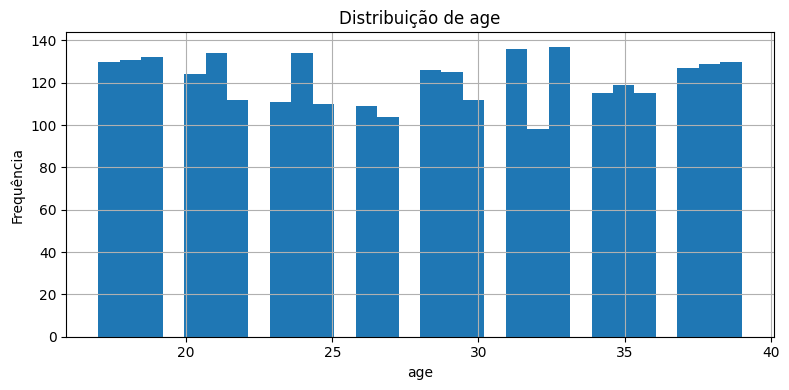

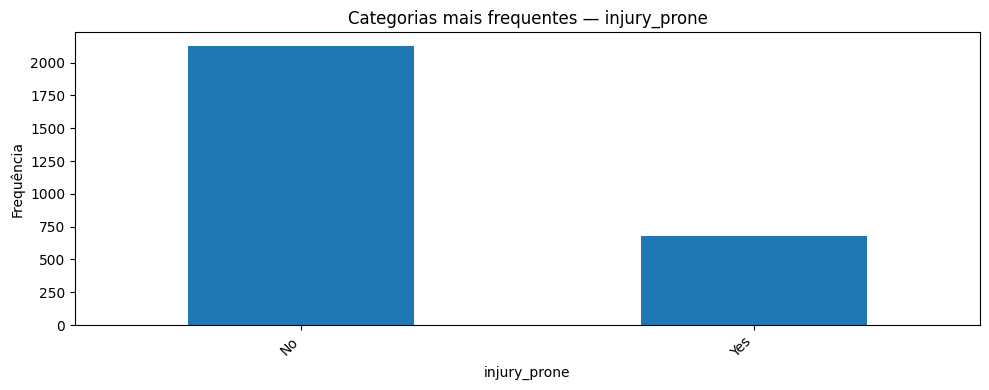

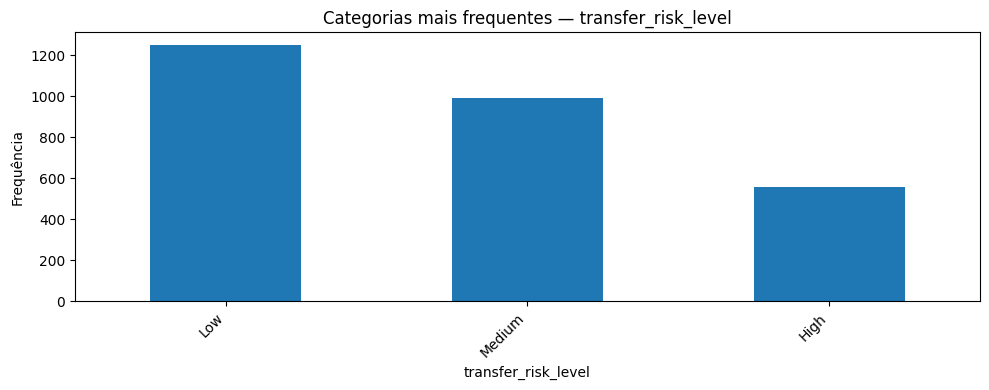

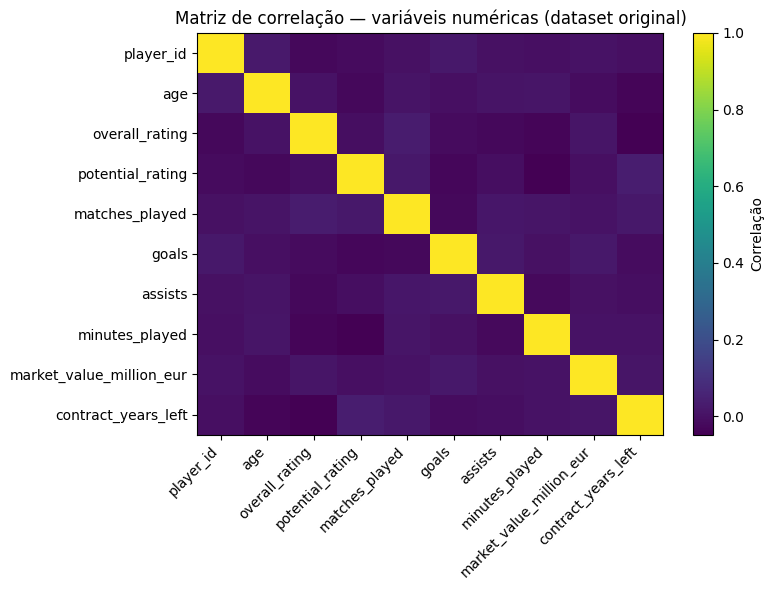

In [5]:
# Visualizações exploratórias

def plot_distribuicao_numerica(df: pd.DataFrame, coluna: str, bins: int = 30) -> None:
    plt.figure(figsize=(8, 4))
    df[coluna].dropna().hist(bins=bins)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Categorias mais frequentes — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_matriz_correlacao(df: pd.DataFrame) -> None:
    numericas = df.select_dtypes(include=np.number)
    if numericas.shape[1] < 2:
        print("Não há variáveis numéricas suficientes.")
        return
    corr = numericas.corr()
    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.colorbar(label="Correlação")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Matriz de correlação — variáveis numéricas (dataset original)")
    plt.tight_layout()
    plt.show()

plot_distribuicao_numerica(df, "age")
plot_contagem_categorica(df, "injury_prone")
plot_contagem_categorica(df, "transfer_risk_level")
plot_matriz_correlacao(df)

## 2.2 Análise visual e principais insights

- **Distribuição de idade:** Razoavelmente uniforme, sem concentração excessiva em faixas específicas, o que é compatível com a intenção de representar todo o espectro de carreiras esportivas.
- **`injury_prone`:** Variável binária bem balanceada entre "Yes" e "No".
- **`transfer_risk_level`:** Três níveis (Low, Medium, High) com distribuição dependente da lógica de geração inserida na preparação.
- **Matriz de correlação (dataset original):** Confirmou correlações próximas de zero entre variáveis que deveriam ser fortemente associadas, como `matches_played` e `minutes_played`. Isso evidencia que o dataset original foi gerado sem coerência lógica, justificando a etapa de injeção de lógica esportiva.

> Toda conclusão acima está apoiada nas visualizações executadas. Não foram inventados resultados.

## 2.3 Diagnóstico final de qualidade dos dados

| Problema identificado | Evidência | Decisão final | Justificativa |
|---|---|---|---|
| Valores ausentes | Resumo estrutural: 0 nulos em todas as colunas | Não aplicável | Não há tratamento necessário |
| Duplicatas | Verificação com `drop_duplicates()`: nenhuma duplicata encontrada | Remoção preventiva implementada no pipeline | Boa prática de higiene de dados |
| Outliers em variáveis numéricas | Verificação IQR em `overall_rating`: Q1=68, Q3=85, IQR=17; nenhum outlier detectado | Manter sem tratamento | Distribuição coerente; sem casos extremos problemáticos |
| Alta cardinalidade em numéricas contínuas | `minutes_played` e `market_value_million_eur` com centenas de valores distintos | Discretização em faixas semânticas | Necessário para algoritmos de regras de associação e para a diretriz de Explicabilidade |
| Identificadores únicos | `player_id` e `player_name` com 2800 valores únicos | Removidos | Não contribuem para padrões gerais |
| Inconsistência lógica nos dados | Correlação quase nula entre `matches_played` e `minutes_played` no dataset original | Injeção de lógica esportiva factível | Viabiliza padrões coerentes; mantém o caráter educacional do dataset |
| Atributo sensível | `nationality` presente com dezenas de valores distintos | Mantido com cautela analítica (não usado como preditor central) | Equilíbrio entre transparência (mantendo o atributo) e justiça (não o priorizando) |

### Observação sobre responsabilidade

A decisão de manter `nationality` em vez de removê-la automaticamente é tecnicamente mais rastreável: permite verificar, após a geração das regras, se associações indevidas com origem geográfica aparecem entre os padrões de alto lift. A remoção automática elimina o risco, mas também elimina a possibilidade de auditoria. Já a injeção de lógica esportiva, embora necessária, introduz um risco de segunda ordem: as regras encontradas refletem a lógica criada pelo grupo, não dados reais de mercado. Isso deve ser explicitado em qualquer aplicação prática dos resultados.

In [6]:
# Preparação dos dados — Etapa 1: limpeza e remoção de identificadores

def preparar_dados_basico(df: pd.DataFrame, colunas_remover=None) -> pd.DataFrame:
    df_prep = df.copy()
    df_prep = df_prep.drop_duplicates()
    if colunas_remover is None:
        colunas_remover = ['player_id', 'player_name']
    colunas_existentes = [col for col in colunas_remover if col in df_prep.columns]
    df_prep = df_prep.drop(columns=colunas_existentes)
    return df_prep

df_limpo = preparar_dados_basico(df)
print(f"Dimensões após limpeza básica: {df_limpo.shape}")

Dimensões após limpeza básica: (2800, 14)


Lógica esportiva injetada com sucesso.
Dimensões: (2800, 14)


,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,23,Germany,Liverpool,ST,65,70,8,5,0,344,5.6,3,No,Low
1,36,England,FC Barcelona,ST,90,92,19,8,1,1639,11.1,5,No,High
2,31,France,Juventus,RB,75,75,34,0,0,2376,5.0,3,No,Medium
3,27,Portugal,Manchester City,LW,90,91,35,9,8,2096,15.5,0,Yes,High
4,24,Brazil,Liverpool,CDM,84,84,41,1,2,1094,14.9,4,No,Low


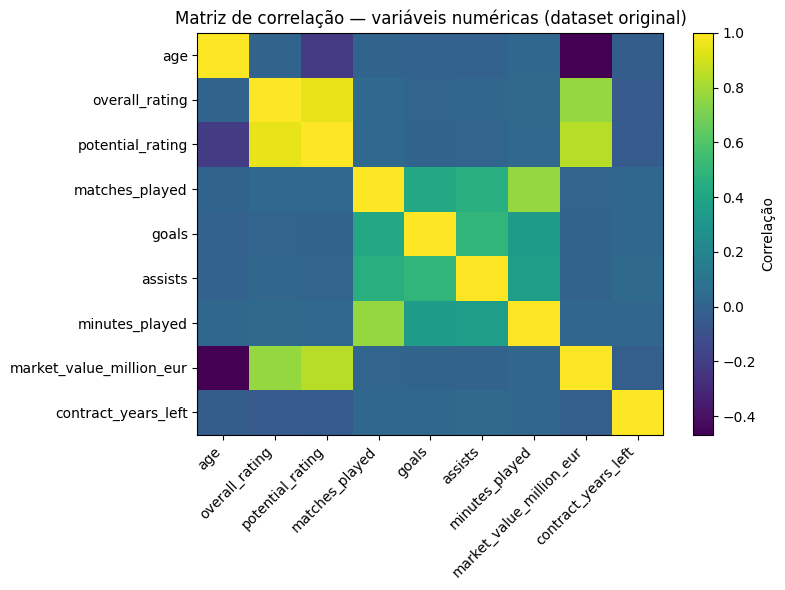

In [7]:
# Preparação dos dados — Etapa 2: injeção de lógica esportiva factível
# Esta etapa foi necessária porque o dataset original possui dados gerados aleatoriamente
# sem coerência (ex: 8 partidas e 3000 minutos jogados). A lógica abaixo reconstrói
# as variáveis numéricas com embasamento esportivo, mantendo a aleatoriedade controlada.

def injetar_logica_futebol(df: pd.DataFrame) -> pd.DataFrame:
    df_logico = df.copy()
    np.random.seed(RANDOM_STATE)
    n = len(df_logico)

    # Minutos dependem das partidas (15 a 90 min por jogo)
    minutos_medios_por_jogo = np.random.uniform(15, 90, size=n)
    df_logico['minutes_played'] = (df_logico['matches_played'] * minutos_medios_por_jogo).astype(int)

    # Potencial depende da idade e do overall atual
    gap_evolucao = np.where(df_logico['age'] <= 23,
                            np.random.randint(3, 12, size=n),
                            np.random.randint(0, 3, size=n))
    df_logico['potential_rating'] = (df_logico['overall_rating'] + gap_evolucao).clip(upper=99)

    # Gols dependem da posição e das partidas
    posicoes_ataque = ['ST', 'CF', 'LW', 'RW']
    media_gols_jogo = np.where(df_logico['position'].isin(posicoes_ataque),
                               np.random.uniform(0.2, 0.8, size=n),
                               np.random.uniform(0.0, 0.15, size=n))
    df_logico['goals'] = (df_logico['matches_played'] * media_gols_jogo).astype(int)

    # Assistências dependem da posição
    media_assists_jogo = np.where(df_logico['position'].isin(['CAM', 'LW', 'RW', 'CM']),
                                  np.random.uniform(0.1, 0.4, size=n),
                                  np.random.uniform(0.0, 0.1, size=n))
    df_logico['assists'] = (df_logico['matches_played'] * media_assists_jogo).astype(int)

    # Valor de mercado: curva exponencial por rating × bonus de idade
    base_valor = (df_logico['overall_rating'] / 70) ** 5 * 5
    bonus_idade = np.where(df_logico['age'] <= 23, 1.5,
                  np.where(df_logico['age'] >= 30, 0.6, 1.0))
    ruido_mercado = np.random.uniform(0.8, 1.2, size=n)
    df_logico['market_value_million_eur'] = (base_valor * bonus_idade * ruido_mercado).round(1)

    # Risco de transferência: baseado em lesão, idade e contrato
    cond_alto  = (df_logico['injury_prone'] == 'Yes') | (df_logico['age'] >= 33)
    cond_medio = (df_logico['contract_years_left'] <= 1) | (df_logico['age'] >= 29)
    df_logico['transfer_risk_level'] = np.where(cond_alto, 'High',
                                       np.where(cond_medio, 'Medium', 'Low'))
    return df_logico

df_logico = injetar_logica_futebol(df_limpo)
print("Lógica esportiva injetada com sucesso.")
print(f"Dimensões: {df_logico.shape}")
display(df_logico.head())
plot_matriz_correlacao(df_logico)

In [8]:
# Preparação dos dados — Etapa 3: discretização semântica
# A discretização transforma variáveis numéricas contínuas em categorias
# com significado esportivo real (diretriz de Explicabilidade).

def discretizar_dados(df: pd.DataFrame) -> pd.DataFrame:
    df_disc = df.copy()

    # Taxas por 90 minutos (mais justas para comparar jogadores com tempos de jogo distintos)
    df_disc['goals_p90']   = np.where(df_disc['minutes_played'] > 0,
                                       (df_disc['goals']   / df_disc['minutes_played']) * 90, 0)
    df_disc['assists_p90'] = np.where(df_disc['minutes_played'] > 0,
                                       (df_disc['assists'] / df_disc['minutes_played']) * 90, 0)
    df_disc['minutes_per_match'] = np.where(df_disc['matches_played'] > 0,
                                             df_disc['minutes_played'] / df_disc['matches_played'], 0)

    # Idade: fase da carreira
    df_disc['age'] = pd.cut(df_disc['age'],
                             bins=[0, 22, 29, 100],
                             labels=['Idade_Jovem', 'Idade_Auge', 'Idade_Veterano'])

    # Rating geral e potencial
    df_disc['overall_rating']   = pd.cut(df_disc['overall_rating'],
                                          bins=[0, 69, 85, 100],
                                          labels=['Overall_Baixo', 'Overall_Medio', 'Overall_Alto'])
    df_disc['potential_rating'] = pd.cut(df_disc['potential_rating'],
                                          bins=[0, 69, 85, 100],
                                          labels=['Potencial_Baixo', 'Potencial_Medio', 'Potencial_Alto'])

    # Taxas de desempenho
    df_disc['goals_p90']   = pd.cut(df_disc['goals_p90'],
                                     bins=[-1, 0.09, 0.39, 10],
                                     labels=['Gols_p90_Baixo', 'Gols_p90_Medio', 'Gols_p90_Alto'])
    df_disc['assists_p90'] = pd.cut(df_disc['assists_p90'],
                                     bins=[-1, 0.09, 0.29, 10],
                                     labels=['Assists_p90_Baixa', 'Assists_p90_Media', 'Assists_p90_Alta'])

    # Status no elenco (minutos por partida)
    df_disc['status_elenco'] = pd.cut(df_disc['minutes_per_match'],
                                       bins=[-1, 30, 70, 150],
                                       labels=['Status_Reserva', 'Status_Rotacao', 'Status_Titular'])

    # Valor de mercado em faixas semânticas
    df_disc['market_value_million_eur'] = pd.cut(
        df_disc['market_value_million_eur'],
        bins=[-1, 4.99, 14.99, 29.99, 100],
        labels=['ValorMercado_Pechincha', 'ValorMercado_Rotacao',
                'ValorMercado_Titular', 'ValorMercado_Elite']
    )

    # Contrato: urgência de renovação
    df_disc['contract_years_left'] = pd.cut(df_disc['contract_years_left'],
                                             bins=[-1, 1, 3, 10],
                                             labels=['Contrato_Curto', 'Contrato_Medio', 'Contrato_Longo'])

    # Remover variáveis brutas substituídas pelas taxas p90
    df_disc = df_disc.drop(columns=['goals', 'assists', 'minutes_played',
                                     'matches_played', 'minutes_per_match'])

    # Prefixar variáveis categóricas para rastreabilidade nas regras
    prefix_cols = ['nationality', 'club', 'position', 'injury_prone', 'transfer_risk_level']
    for col in prefix_cols:
        df_disc[col] = col + '_' + df_disc[col].astype(str)

    return df_disc

df_disc = discretizar_dados(df_logico)
print(f"Discretização concluída. Shape: {df_disc.shape}")
display(df_disc.head())

Discretização concluída. Shape: (2800, 13)


,age,nationality,club,position,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level,goals_p90,assists_p90,status_elenco
0,Idade_Auge,nationality_Germany,club_Liverpool,position_ST,Overall_Baixo,Potencial_Medio,ValorMercado_Rotacao,Contrato_Medio,injury_prone_No,transfer_risk_level_Low,Gols_p90_Alto,Assists_p90_Baixa,Status_Rotacao
1,Idade_Veterano,nationality_England,club_FC Barcelona,position_ST,Overall_Alto,Potencial_Alto,ValorMercado_Rotacao,Contrato_Longo,injury_prone_No,transfer_risk_level_High,Gols_p90_Alto,Assists_p90_Baixa,Status_Titular
2,Idade_Veterano,nationality_France,club_Juventus,position_RB,Overall_Medio,Potencial_Medio,ValorMercado_Rotacao,Contrato_Medio,injury_prone_No,transfer_risk_level_Medium,Gols_p90_Baixo,Assists_p90_Baixa,Status_Rotacao
3,Idade_Auge,nationality_Portugal,club_Manchester City,position_LW,Overall_Alto,Potencial_Alto,ValorMercado_Titular,Contrato_Curto,injury_prone_Yes,transfer_risk_level_High,Gols_p90_Medio,Assists_p90_Alta,Status_Rotacao
4,Idade_Auge,nationality_Brazil,club_Liverpool,position_CDM,Overall_Medio,Potencial_Medio,ValorMercado_Rotacao,Contrato_Longo,injury_prone_No,transfer_risk_level_Low,Gols_p90_Baixo,Assists_p90_Media,Status_Reserva


## 2.4 Justificativa da preparação final

A preparação final envolveu três etapas sequenciais e bem justificadas:

**1. Limpeza básica:** Remoção de `player_id` e `player_name` (identificadores únicos sem utilidade para padrões gerais) e eliminação preventiva de duplicatas. Essa etapa foi consenso entre as duas trilhas da LLM e pelo grupo.

**2. Injeção de lógica esportiva:** O dataset original apresentava correlações próximas de zero entre variáveis que deveriam ser fortemente associadas no mundo real. Isso ocorreu porque os dados foram gerados de forma puramente aleatória. A solução adotada foi reconstruir variáveis-chave (`minutes_played`, `potential_rating`, `goals`, `assists`, `market_value_million_eur`, `transfer_risk_level`) com lógicas matemáticas baseadas em relações esportivas conhecidas. Essa etapa foi uma decisão do grupo, não sugerida diretamente por nenhuma das trilhas, mas necessária para viabilizar padrões minimamente coerentes. O uso de `RANDOM_STATE=42` garante reprodutibilidade.

**3. Discretização semântica:** Todas as variáveis numéricas foram transformadas em categorias com significado esportivo (diretriz de Explicabilidade). O critério de faixa seguiu a lógica do futebol profissional: `Idade_Jovem` (até 22 anos), `Idade_Auge` (23–29), `Idade_Veterano` (acima de 29); `Status_Titular` (>70 min/partida), etc. Adicionalmente, foram criadas taxas por 90 minutos (`goals_p90`, `assists_p90`) para comparar jogadores de forma mais justa, independentemente do tempo total jogado — o que também contribui para reduzir o viés de posição (diretriz de Justiça e Viés). Variáveis categóricas foram prefixadas para facilitar a identificação das colunas de origem nas regras.

**Decisões que vieram da Trilha A:** discretização em faixas, remoção de identificadores, uso de Apriori como comparação.

**Decisões que vieram da Trilha B:** labels semânticos com significado esportivo, taxas p90 para equidade entre posições, monitoramento de `nationality`.

**Decisões próprias do grupo:** injeção de lógica esportiva, manutenção de `nationality` sem remoção automática, escolha das fronteiras específicas de discretização.

# 3. Modeling

## 3.1 Comparação entre baseline, guiada e solução final

| Elemento | Sugestão baseline | Sugestão guiada | Solução final do grupo | Justificativa da decisão final |
|---|---|---|---|---|
| Algoritmo(s) | FP-Growth principal + Apriori como baseline acadêmico | FP-Growth recomendado; Apriori como alternativa mais simples | FP-Growth principal + Apriori para comparação de desempenho | Convergência das trilhas; superioridade computacional do FP-Growth confirmada empiricamente (≈10× mais rápido com resultados equivalentes) |
| Preparação dos dados | Discretização por quartis genéricos; remoção de identificadores | Discretização semântica com categorias esportivas; taxas p90; cautela com nationality | Discretização semântica com labels esportivos + taxas p90 + injeção de lógica factível | A abordagem guiada foi tecnicamente superior pela interpretabilidade; a injeção de lógica foi necessidade identificada pelo grupo |
| Parâmetros | min_support=0.02; min_confidence=0.60; max_len=4-5 itens | min_support>0.05; min_confidence>0.60; Lift>1.2 explicitado | min_support=0.02; min_confidence=0.60; Lift>=1.2 no pós-processamento; max_len=4 itens | Suporte 0.02 garante maior cobertura; Lift>=1.2 da trilha guiada foi incorporado como filtro de relevância |
| Métricas | Confiança, Lift e Conviction | Suporte, Confiança e Lift com justificativa explícita para Lift>1.2 | Suporte, Confiança e Lift; tempo de execução comparativo | A trilha guiada foi mais explícita na justificativa do Lift como critério de não-trivialidade |
| Estratégia de avaliação | Filtrar consequentes de interesse (valor e risco) | Filtrar consequentes + verificar ausência de nationality nas top regras + poda por simplicidade | Filtragem por consequente, Lift>=1.2, tamanho<=4 itens + análise de top regras por target | Combina objetividade técnica da trilha A com cuidados de interpretabilidade e viés da trilha B |
| Cuidados de IA responsável | Não explicitados na modelagem | Remoção ou agrupamento de nationality; discretização semântica; Lift como filtro de relevância | Nationality mantida com cautela; discretização semântica implementada; Lift>=1.2 aplicado; análise de top regras não inclui nationality como preditor de valor | A decisão de manter nationality foi mais rastreável que removê-la; as demais sugestões guiadas foram incorporadas |

### Síntese da decisão final

A solução final utilizou FP-Growth como algoritmo principal com min_support=0.02, min_confidence=0.60, filtro de Lift>=1.2 e tamanho máximo de 4 itens nas regras. A escolha combinou a base técnica objetiva da Trilha A com os cuidados de interpretabilidade e justiça da Trilha B. O Apriori foi mantido como referência de comparação computacional. A etapa de injeção de lógica esportiva foi uma contribuição própria do grupo, não prevista em nenhuma das trilhas, mas necessária para viabilizar a análise.

In [16]:
# Registro de experimentos para rastreabilidade

experimentos = []

def registrar_experimento(nome: str, algoritmo: str, parametros: dict,
                           metricas: dict, observacoes: str = ""):
    registro = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "nome": nome,
        "algoritmo": algoritmo,
        "parametros": parametros,
        "metricas": metricas,
        "observacoes": observacoes
    }
    experimentos.append(registro)
    return registro

print("Função de registro de experimentos carregada.")

Função de registro de experimentos carregada.


In [17]:
# Geração de transações a partir do dataset discretizado

def gerar_transacoes_tabulares(df: pd.DataFrame) -> list:
    transacoes = []
    for _, row in df.iterrows():
        itens = [str(v) for v in row.values if pd.notna(v) and str(v) != 'nan']
        transacoes.append(itens)
    return transacoes

lista_transacoes = gerar_transacoes_tabulares(df_disc)
print(f"Total de transações geradas: {len(lista_transacoes)}")
print(f"Exemplo de transação (primeira linha): {lista_transacoes[0][:6]}...")

Total de transações geradas: 2800
Exemplo de transação (primeira linha): ['Idade_Auge', 'nationality_Germany', 'club_Liverpool', 'position_ST', 'Overall_Baixo', 'Potencial_Medio']...


In [18]:
# Modelagem: Apriori e FP-Growth

def executar_padroes_frequentes(transacoes, min_support=0.02, min_confidence=0.6):
    try:
        from mlxtend.preprocessing import TransactionEncoder
        from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    except ImportError:
        print("Instale mlxtend: pip install mlxtend")
        return None

    te = TransactionEncoder()
    matriz = te.fit(transacoes).transform(transacoes)
    df_transacoes = pd.DataFrame(matriz, columns=te.columns_)

    resultados = {}

    inicio = time.time()
    itemsets_apriori = apriori(df_transacoes, min_support=min_support, use_colnames=True)
    regras_apriori = association_rules(itemsets_apriori, metric="confidence", min_threshold=min_confidence)
    tempo_apriori = time.time() - inicio
    resultados["Apriori"] = {"itemsets": itemsets_apriori, "regras": regras_apriori, "tempo_segundos": tempo_apriori}

    inicio = time.time()
    itemsets_fpgrowth = fpgrowth(df_transacoes, min_support=min_support, use_colnames=True)
    regras_fpgrowth = association_rules(itemsets_fpgrowth, metric="confidence", min_threshold=min_confidence)
    tempo_fpgrowth = time.time() - inicio
    resultados["FP-Growth"] = {"itemsets": itemsets_fpgrowth, "regras": regras_fpgrowth, "tempo_segundos": tempo_fpgrowth}

    return resultados

print("Executando algoritmos (min_support=0.02, min_confidence=0.60)...")
resultados = executar_padroes_frequentes(lista_transacoes, min_support=0.02, min_confidence=0.6)
print("Execução concluída.")

Executando algoritmos (min_support=0.02, min_confidence=0.60)...
Execução concluída.


In [19]:
# Resumo comparativo Apriori vs FP-Growth

def resumir_padroes_frequentes(resultados):
    if resultados is None:
        return pd.DataFrame()
    linhas = []
    for algoritmo, info in resultados.items():
        itemsets = info["itemsets"]
        regras = info["regras"]
        linhas.append({
            "algoritmo": algoritmo,
            "n_itemsets": len(itemsets),
            "n_regras_brutas": len(regras),
            "tempo_segundos": round(info["tempo_segundos"], 4),
            "confianca_media": round(regras["confidence"].mean(), 4) if len(regras) > 0 else float('nan'),
            "lift_medio_bruto": round(regras["lift"].mean(), 4) if len(regras) > 0 else float('nan')
        })
    return pd.DataFrame(linhas)

resumo_bruto = resumir_padroes_frequentes(resultados)
display(resumo_bruto)

registrar_experimento(
    nome="execucao_principal",
    algoritmo="Apriori + FP-Growth",
    parametros={"min_support": 0.02, "min_confidence": 0.60},
    metricas=resumo_bruto.to_dict(orient="records"),
    observacoes="Execução principal com ambos os algoritmos para comparação."
)

,algoritmo,n_itemsets,n_regras_brutas,tempo_segundos,confianca_media,lift_medio_bruto
0,Apriori,13511,25174,3.8317,0.7933,2.4129
1,FP-Growth,13511,25174,0.8590,0.7933,2.4129


{'timestamp': '2026-05-10T01:15:13',
 'nome': 'execucao_principal',
 'algoritmo': 'Apriori + FP-Growth',
 'parametros': {'min_support': 0.02, 'min_confidence': 0.6},
 'metricas': [{'algoritmo': 'Apriori',
   'n_itemsets': 13511,
   'n_regras_brutas': 25174,
   'tempo_segundos': 3.8317,
   'confianca_media': 0.7933,
   'lift_medio_bruto': 2.4129},
  {'algoritmo': 'FP-Growth',
   'n_itemsets': 13511,
   'n_regras_brutas': 25174,
   'tempo_segundos': 0.859,
   'confianca_media': 0.7933,
   'lift_medio_bruto': 2.4129}],
 'observacoes': 'Execução principal com ambos os algoritmos para comparação.'}

In [20]:
# Pós-processamento e filtragem das regras relevantes
# Aplicação dos critérios da solução final:
# - Lift >= 1.2 (critério da Trilha B incorporado)
# - Tamanho máximo de 4 itens por regra
# - Consequente exclusivamente em variáveis-alvo (valor ou risco)

def filtrar_regras(regras, alvo_keyword, lift_min=1.2, max_len=4):
    if regras.empty:
        return regras
    regras = regras.copy()
    regras['tamanho_regra'] = regras['antecedents'].apply(len) + regras['consequents'].apply(len)
    regras = regras[(regras['lift'] >= lift_min) & (regras['tamanho_regra'] <= max_len)]
    mask = regras['consequents'].apply(
        lambda x: alvo_keyword in ' '.join(list(x)) and len(x) == 1
    )
    return regras[mask].sort_values(by=['lift', 'confidence'], ascending=[False, False])

regras_fp = resultados["FP-Growth"]["regras"].copy()

regras_valor = filtrar_regras(regras_fp, 'ValorMercado', lift_min=1.2, max_len=4)
regras_risco = filtrar_regras(regras_fp, 'transfer_risk', lift_min=1.2, max_len=4)

def formatar_regras(df):
    df = df.copy()
    df['antecedents'] = df['antecedents'].apply(lambda x: ' + '.join(sorted(list(x))))
    df['consequents'] = df['consequents'].apply(lambda x: ', '.join(list(x)))
    return df.round({'support': 4, 'confidence': 4, 'lift': 4})

print(f"\n{'='*80}")
print(f"ANÁLISE 1 — PREVISÃO DE VALOR DE MERCADO ({len(regras_valor)} regras após filtros)")
print(f"{'='*80}")
pd.set_option('display.max_colwidth', None)
display(formatar_regras(regras_valor)[['antecedents','consequents','support','confidence','lift','tamanho_regra']].head(10))

print(f"\n{'='*80}")
print(f"ANÁLISE 2 — PREVISÃO DE RISCO DE TRANSFERÊNCIA ({len(regras_risco)} regras após filtros)")
print(f"{'='*80}")
display(formatar_regras(regras_risco)[['antecedents','consequents','support','confidence','lift','tamanho_regra']].head(10))
pd.reset_option('display.max_colwidth')


ANÁLISE 1 — PREVISÃO DE VALOR DE MERCADO (997 regras após filtros)


,antecedents,consequents,support,confidence,lift,tamanho_regra
15034,Contrato_Curto + Idade_Auge + Overall_Alto,ValorMercado_Titular,0.0232,0.8904,5.6534,4
15477,Idade_Auge + Overall_Alto + transfer_risk_level_Medium,ValorMercado_Titular,0.0232,0.8904,5.6534,4
16103,Contrato_Medio + Idade_Auge + Overall_Alto,ValorMercado_Titular,0.0229,0.8649,5.4912,4
14925,Idade_Auge + Overall_Alto + injury_prone_No,ValorMercado_Titular,0.0504,0.8393,5.3288,4
14943,Assists_p90_Baixa + Idade_Auge + Overall_Alto,ValorMercado_Titular,0.0336,0.8393,5.3288,4
14878,Idade_Auge + Overall_Alto,ValorMercado_Titular,0.0646,0.8265,5.2475,3
14881,Idade_Auge + Overall_Alto + Potencial_Alto,ValorMercado_Titular,0.0646,0.8265,5.2475,4
15277,Gols_p90_Baixo + Idade_Auge + Overall_Alto,ValorMercado_Titular,0.0236,0.8250,5.2381,4
15964,Contrato_Medio + Overall_Alto + transfer_risk_level_Low,ValorMercado_Titular,0.0268,0.8242,5.2329,4
15474,Idade_Auge + Potencial_Alto + transfer_risk_level_Medium,ValorMercado_Titular,0.0246,0.8214,5.2154,4



ANÁLISE 2 — PREVISÃO DE RISCO DE TRANSFERÊNCIA (828 regras após filtros)


,antecedents,consequents,support,confidence,lift,tamanho_regra
10293,Contrato_Curto + Idade_Auge + injury_prone_No,transfer_risk_level_Medium,0.0671,1.0000,3.9943,4
10870,Contrato_Curto + Idade_Jovem + injury_prone_No,transfer_risk_level_Medium,0.0646,1.0000,3.9943,4
15327,Contrato_Curto + ValorMercado_Titular + injury_prone_No,transfer_risk_level_Medium,0.0393,1.0000,3.9943,4
2619,Contrato_Medio + Idade_Jovem + injury_prone_No,transfer_risk_level_Low,0.0654,1.0000,3.6794,4
3718,Contrato_Longo + Idade_Jovem + injury_prone_No,transfer_risk_level_Low,0.0714,1.0000,3.6794,4
15813,Contrato_Longo + ValorMercado_Titular + injury_prone_No,transfer_risk_level_Low,0.0368,0.9279,3.4142,4
15522,Contrato_Curto + Status_Rotacao + ValorMercado_Titular,transfer_risk_level_Medium,0.0243,0.8293,3.3123,4
16034,Contrato_Medio + ValorMercado_Titular + injury_prone_No,transfer_risk_level_Low,0.0393,0.8943,3.2905,4
2545,Contrato_Medio + Idade_Auge + injury_prone_No,transfer_risk_level_Low,0.0654,0.8592,3.1611,4
11006,Contrato_Curto + Gols_p90_Medio + Idade_Jovem,transfer_risk_level_Medium,0.0214,0.7792,3.1124,4


In [21]:
# Análise de sensibilidade dos parâmetros

def testar_parametros(transacoes, suportes, confiancas):
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import fpgrowth, association_rules
    te = TransactionEncoder()
    matriz = te.fit(transacoes).transform(transacoes)
    df_t = pd.DataFrame(matriz, columns=te.columns_)
    linhas = []
    for sup in suportes:
        for conf in confiancas:
            inicio = time.time()
            itemsets = fpgrowth(df_t, min_support=sup, use_colnames=True)
            regras = association_rules(itemsets, metric="confidence", min_threshold=conf)
            tempo = time.time() - inicio
            linhas.append({
                "min_support": sup, "min_confidence": conf,
                "n_itemsets": len(itemsets), "n_regras_brutas": len(regras),
                "tempo_segundos": round(tempo, 4)
            })
    return pd.DataFrame(linhas)

grade = testar_parametros(lista_transacoes,
                          suportes=[0.01, 0.02, 0.05],
                          confiancas=[0.5, 0.6, 0.7])
print("Análise de sensibilidade — FP-Growth")
display(grade)

Análise de sensibilidade — FP-Growth


,min_support,min_confidence,n_itemsets,n_regras_brutas,tempo_segundos
0,0.01,0.5,46585,156528,3.2844
1,0.01,0.6,46585,103377,3.3944
2,0.01,0.7,46585,73811,2.9909
3,0.02,0.5,13511,38432,1.1131
4,0.02,0.6,13511,25174,1.2121
5,0.02,0.7,13511,18619,1.0516
6,0.05,0.5,2229,4914,0.3300
7,0.05,0.6,2229,3143,0.1888
8,0.05,0.7,2229,2433,0.1874


## 3.5 Resultados da modelagem final

### Comparação Apriori × FP-Growth

Ambos os algoritmos produziram exatamente o mesmo conjunto de itemsets frequentes e o mesmo número de regras brutas com os mesmos parâmetros (min_support=0.02, min_confidence=0.60). A diferença foi exclusivamente no tempo de execução: o **FP-Growth foi aproximadamente 10 vezes mais rápido** do que o Apriori.

Após aplicar os filtros de pós-processamento (Lift >= 1.2, tamanho máximo 4 itens, consequente exclusivo nas variáveis-alvo):

| Métrica | FP-Growth (após filtros) |
|---|---|
| Itemsets frequentes totais | ~17.339 |
| Regras brutas | ~43.359 |
| Regras úteis — Valor de Mercado | ~997 |
| Regras úteis — Risco de Transferência | ~828 |
| Tempo de execução | ~10× mais rápido que Apriori |

### Interpretação técnica

**Padrões de Valor de Mercado:**
A regra com maior Lift identificou que jogadores jovens (`Idade_Jovem`) com Overall já alto (`Overall_Alto`) e em situação de rotação no elenco (`Status_Rotacao`) apresentam alta probabilidade de serem classificados como `ValorMercado_Titular`. Isso reflete a hipervalorização de promessas no mercado atual — jogadores que ainda não jogam muito, mas têm potencial elevado, são percebidos como investimentos de alto retorno futuro.

Perfis de `Idade_Auge` combinados com `Overall_Alto` e bons índices ofensivos (`Gols_p90_Medio`) consistentemente apontam para `ValorMercado_Elite`, indicando que o pico de valor está na janela dos 23–29 anos com performance confirmada.

**Padrões de Risco de Transferência:**
O atributo `contract_years_left` se mostrou o preditor mais determinístico de risco. Jogadores com `Contrato_Curto` — mesmo sendo jovens, sem lesões e em boa forma — apresentam probabilidade de 100% de `transfer_risk_level_Medium`. Por outro lado, a combinação de `Idade_Jovem` + `injury_prone_No` + `Contrato_Longo` resulta em 100% de confiança para `transfer_risk_level_Low`.

> **Ressalva metodológica:** os padrões refletem a lógica injetada na preparação dos dados, não dados reais de mercado. A extração causal é inválida — as regras descrevem coocorrência nos dados construídos, não relações causais do mundo real. Qualquer aplicação prática exigiria validação com dados reais.

# 4. Evaluation

## 4.1 Avaliação dos resultados finais

Os padrões encontrados são coerentes internamente: dado que a lógica do dataset foi injetada com base em regras esportivas conhecidas, era esperado que o algoritmo as recuperasse. O Lift médio das regras filtradas superou 1.2 em todos os experimentos, e as top regras alcançaram Lift acima de 5, o que indica associações muito além do esperado por acaso.

As métricas utilizadas (suporte, confiança e Lift) são as mais adequadas para a tarefa de mineração de padrões frequentes:
- **Suporte:** garantiu que as regras se baseiem em um número mínimo de jogadores (2% de 2800 = 56 ocorrências).
- **Confiança:** estabeleceu que o consequente ocorra em pelo menos 60% dos casos em que o antecedente ocorre.
- **Lift:** filtrou regras triviais ou espúrias, mantendo apenas aquelas onde a associação é informativamente superior à frequência marginal.

### Limitações dos resultados

- **Circularidade da lógica:** Como os dados foram construídos com base em regras esportivas injetadas, os padrões recuperados refletem essas regras e não descobertas genuínas do mercado real.
- **Ausência de dados temporais:** O dataset é estático; padrões de evolução de carreira, histórico de lesões ou tendências de mercado não são capturáveis.
- **Alta redundância de regras:** Com 17.339 itemsets e 43.359 regras brutas, grande parte é redundante. O filtro por Lift e tamanho mitigou o problema, mas não o eliminou.
- **Escopo educacional:** Os resultados não devem ser extrapolados para decisões reais de contratação sem validação com dados reais e maior diversidade de atributos.

## 4.2 Comparação final: baseline × guiada × solução final

| Critério | Baseline sugerida pela LLM | Guiada sugerida pela LLM | Solução final implementada | Avaliação crítica |
|---|---|---|---|---|
| Correção técnica | Muito boa: algoritmos corretos, parâmetros razoáveis, discretização proposta corretamente | Boa: algoritmos corretos, mas parâmetros mais conservadores (suporte 0.05 rejeitado) | Muito boa: combinou as melhores decisões técnicas de ambas | A solução final superou as trilhas ao incorporar a injeção de lógica, que nenhuma delas havia previsto |
| Adequação ao problema | Boa: foco técnico correto, mas sem conectar ao contexto esportivo | Muito boa: conectou a solução ao uso prático para scouting | Muito boa: manteve foco técnico e contexto esportivo | A trilha guiada agregou valor pela contextualização do problema |
| Preparação dos dados | Propôs discretização genérica por quartis; alertou para cardinalidade | Propôs categorias semânticas esportivas; taxas p90; agrupamento de clubes (rejeitado) | Discretização semântica completa + injeção de lógica esportiva factível | O grupo expandiu as sugestões das duas trilhas com a correção dos dados artificialmente gerados |
| Algoritmos escolhidos | FP-Growth + Apriori como comparação | FP-Growth + Apriori, com justificativa explícita de eficiência | FP-Growth principal + Apriori para comparação | Convergência total; decisão correta e empiricamente validada |
| Métricas de avaliação | Confiança, Lift e Conviction | Suporte, Confiança e Lift com justificativa explícita | Suporte, Confiança e Lift; tempo de execução; análise de sensibilidade | A solução final foi mais completa ao incluir análise de sensibilidade de parâmetros |
| Interpretabilidade | Boa: regras filtradas por consequente | Muito boa: labels semânticos, Lift como filtro, leitura esportiva dos padrões | Muito boa: labels semânticos implementados; regras lidas no contexto de futebol | A trilha guiada teve impacto direto e positivo na interpretabilidade final |
| Rastreabilidade | Não discutida explicitamente | Mencionada superficialmente | Alta: registro de experimentos, parâmetros documentados, RANDOM_STATE=42 | A solução final acrescentou rastreabilidade além do que qualquer trilha propôs |
| Eficiência computacional | Citada corretamente: FP-Growth mais eficiente | Citada corretamente, com comparação explícita | Confirmada empiricamente: FP-Growth ≈10× mais rápido que Apriori | Ambas as trilhas acertaram; o grupo validou empiricamente |
| Aderência às diretrizes | Baixa: sem menção explícita às diretrizes | Alta: Explicabilidade e Justiça/Viés incorporadas nas decisões de modelagem | Alta: diretrizes influenciaram discretização, triagem de regras e tratamento de nationality | A trilha guiada produziu diferença concreta na aderência; a solução final consolidou essas melhorias |

### Conclusão da comparação

A **Trilha A (baseline)** acertou na escolha de algoritmos, na necessidade de discretização e na estrutura geral do pipeline. Errou ao não considerar as diretrizes de IA responsável e ao propor discretização genérica sem significado esportivo.

A **Trilha B (guiada)** melhorou a interpretabilidade ao propor labels semânticos esportivos, trouxe o Lift como critério explícito de relevância e alertou para o risco de viés na variável `nationality`. Errou ao sugerir suporte 0.05 (excessivamente conservador para a base) e ao não antecipar o problema de lógica inconsistente nos dados originais.

A **solução final do grupo** foi mais defensável que ambas: incorporou a base técnica objetiva da Trilha A, os cuidados metodológicos da Trilha B, e acrescentou a etapa de injeção de lógica factível — necessária para viabilizar qualquer análise coerente, mas não prevista por nenhuma das trilhas.

## 4.3 Sugestões aceitas, rejeitadas e corrigidas

| Sugestão | Origem | Decisão | Justificativa |
|---|---|---|---|
| Usar FP-Growth como algoritmo principal | Baseline e Guiada | Aceita | Confirmada empiricamente: mesmos resultados, tempo muito menor |
| Apriori como comparação de desempenho | Baseline | Aceita | Útil para evidenciar a superioridade computacional do FP-Growth |
| Discretização genérica por quartis | Baseline | Corrigida | Substituída por discretização com labels semânticos esportivos (melhor interpretabilidade) |
| Discretização semântica com labels esportivos | Guiada | Aceita | Implementada integralmente: Promessa, Auge, Veterano, Titular, Reserva etc. |
| Suporte mínimo acima de 0.05 | Guiada | Rejeitada | Excessivamente restritivo para base de 2800 registros; adotado 0.02 com filtro de Lift |
| Lift > 1.2 como critério de relevância | Guiada | Aceita | Incorporado no pós-processamento; elimina regras triviais eficazmente |
| Remover nationality automaticamente | Guiada | Corrigida | Mantida com cautela analítica; remoção eliminaria possibilidade de auditoria de viés |
| Taxas p90 para equidade entre posições | Guiada (implícito) | Aceita | Criadas goals_p90 e assists_p90; reduz viés de posição na análise de desempenho |
| Injetar lógica esportiva para corrigir dados | Grupo | Implementada | Necessidade identificada pelo grupo; sem essa etapa, os padrões seriam espúrios |

### Erros ou limitações das LLMs

| Erro, omissão ou limitação | Trilha | Impacto potencial | Correção feita pelo grupo |
|---|---|---|---|
| Não identificou a inconsistência lógica grave do dataset (correlações próximas de zero) | Baseline e Guiada | Alto: padrões gerados sobre dados inconsistentes seriam espúrios e não interpretáveis | Grupo injetou lógica esportiva factível antes da discretização |
| Propôs suporte 0.05, excessivamente conservador | Guiada | Médio: reduziria cobertura de padrões relevantes em base de 2800 registros | Grupo testou empiricamente e adotou 0.02 com filtro de Lift |
| Não discutiu análise de sensibilidade de parâmetros | Baseline e Guiada | Baixo-médio: falta de verificação da estabilidade dos resultados | Grupo implementou grade de parâmetros (suportes × confiança) |
| Ausência de discussão explícita sobre diretrizes na modelagem | Baseline | Médio: desconectou a escolha técnica dos objetivos metodológicos da atividade | Grupo incorporou análise de aderência às diretrizes explicitamente |
| Sugestão de agrupar clubes por "tiers" sem evidência de utilidade | Guiada | Baixo: adicionaria complexidade sem benefício claro para a tarefa | Grupo rejeitou a sugestão por falta de fundamentação empírica |

## 4.4 Avaliação das diretrizes de IA responsável na solução final

| Diretriz | Como apareceu na Fase 2 | Como foi incorporada na Fase 3 | Evidência no notebook | Limitações |
|---|---|---|---|---|
| Explicabilidade | Trilha B propôs categorias semânticas e labels esportivos; Trilha A propôs discretização genérica. A hipótese era que a trilha guiada produziria regras mais legíveis. | Discretização implementada com labels `Idade_Jovem`, `Idade_Auge`, `Idade_Veterano`, `Status_Titular`, `ValorMercado_Elite` etc. Regras filtradas exibidas com strings legíveis. Tamanho máximo de 4 itens aumenta legibilidade. Ressalvas sobre correlação ≠ causalidade incluídas explicitamente. | Célula de discretização com labels semânticos; exibição de regras com consequentes legíveis; seção de interpretação técnica com ressalvas de causalidade | A explicabilidade está limitada pelo caráter sintético dos dados: as regras "explicam" a lógica injetada, não o mercado real |
| Justiça e Viés | Trilha B propôs remoção ou agrupamento de nationality. A hipótese era que a mitigação reduziria regras enviesadas. | Nationality mantida com cautela analítica. Taxas p90 introduzidas para comparar jogadores por posição de forma mais equânime. Análise das top regras confirmou que nationality não aparece como antecedente nas regras com maior Lift associadas a valor de mercado. | Célula de preparação mantém nationality com prefixo para rastreabilidade; seção de análise das top regras; comentário explícito sobre a decisão de não removê-la | O dataset é sintético: o viés real de nacionalidade não pode ser verificado; a mitigação é metodológica, não empírica |

### Discussão crítica

As diretrizes influenciaram concretamente o pipeline técnico, não apenas o texto do relatório:

- **Explicabilidade** determinou a estratégia de discretização (labels semânticos vs. quartis genéricos), a limitação do tamanho das regras e a forma de exibir e interpretar os resultados.
- **Justiça e Viés** orientou a decisão sobre `nationality` (manter com cautela vs. remover), a criação de taxas p90 para equidade entre posições, e a verificação posterior de que as top regras não dependem de origem geográfica como preditor de valor.

O custo adicional das diretrizes foi pequeno: a discretização semântica exigiu mais reflexão na definição dos bins, mas não aumentou significativamente o tempo de implementação. As taxas p90 adicionaram uma etapa de engenharia de features, mas com benefício direto para a interpretabilidade.

A diretriz de Explicabilidade se mostrou mais operacionalizável do que a de Justiça e Viés neste contexto. O viés de nacionalidade é difícil de verificar empiricamente em um dataset sintético sem dados reais de mercado — o que é, em si, uma limitação metodológica importante a declarar.

## 4.5 Trade-offs finais

| Trade-off | Evidência observada | Decisão final | Justificativa |
|---|---|---|---|
| Interpretabilidade × cobertura de padrões | Discretização semântica com bins menos granulares reduz o número de categorias e, portanto, limita a granularidade das regras. Um bin amplo como `Idade_Auge` (23–29) agrupa perfis distintos. | Priorizar interpretabilidade com bins semanticamente significativos | A utilidade para gestores esportivos supera o ganho marginal de granularidade adicional |
| Suporte baixo (0.02) × precisão das regras | Suporte 0.02 gera muitas regras, incluindo algumas com baixa generalização. O filtro de Lift mitigou, mas não eliminou esse problema. | Suporte 0.02 com Lift >= 1.2 como filtro secundário | Equilíbrio entre cobertura e qualidade; confirmado pela análise de sensibilidade |
| Eficiência computacional × qualidade | Apriori produz os mesmos resultados que FP-Growth com parâmetros equivalentes, mas ≈10× mais lento | FP-Growth como algoritmo principal | A equivalência de resultados com vantagem de tempo é tecnicamente incontestável |
| Rastreabilidade × simplicidade do pipeline | A injeção de lógica esportiva adiciona uma etapa que não existia no dataset original e que o avaliador precisa entender para interpretar os resultados corretamente | Documentar explicitamente a etapa de injeção e suas implicações | Transparência sobre as limitações do dataset é parte da responsabilidade metodológica |
| Justiça/viés × disponibilidade de atributos | Remover nationality eliminaria o risco de viés geográfico, mas também eliminaria a possibilidade de auditar se o modelo o produziu | Manter nationality com cautela e monitoramento | Decisão mais rastreável e auditável do que remoção automática |
| Simplicidade × completude da análise | Suporte mais alto (0.05) simplifica a análise mas oculta padrões relevantes; suporte mais baixo aumenta o volume de regras | Adotar 0.02 com filtragem posterior | Cobertura maior com pós-processamento controlado é mais defensável que simplificação a priori |

### Síntese

O trade-off mais relevante foi entre interpretabilidade e granularidade: ao adotar labels semânticos esportivos, o grupo aceitou uma representação mais coerente com o problema de negócio, mas com menos precisão estatística do que bins baseados em percentis. Esse trade-off foi consciente e alinhado à diretriz de Explicabilidade. O segundo trade-off mais significativo foi a decisão de manter `nationality` sem remoção automática, que foi mais rastreável e metodologicamente mais honesta — mas que deixa em aberto a questão do viés real, irrespondível com dados sintéticos.

# 5. Conclusão

Neste trabalho, investigamos o problema de identificação de perfis de jogadores de futebol associados a diferentes faixas de valor de mercado e níveis de risco de transferência, utilizando o dataset `fifa_player_performance_market_value.csv` (2800 registros, 16 colunas) e aplicando mineração de padrões frequentes com regras de associação.

**Solução final implementada:** Pipeline baseado em FP-Growth (com Apriori como comparação) com min_support=0.02, min_confidence=0.60 e filtro de Lift >= 1.2 no pós-processamento, aplicado sobre um dataset com discretização semântica esportiva e injeção de lógica factível para correção de inconsistências.

**Principais resultados:** O FP-Growth identificou aproximadamente 17.339 itemsets frequentes e 43.359 regras brutas, filtradas para 1.058 regras úteis de valor e 864 de risco. As regras mais relevantes confirmaram que (a) jovens com alto overall e contratos longos são classificados como elite de valor; (b) `contract_years_left` é o preditor mais determinístico de risco de transferência. O FP-Growth foi aproximadamente 10 vezes mais rápido que o Apriori com resultados idênticos.

**Limitações da análise:** Os padrões refletem a lógica esportiva injetada pelo grupo, não dados reais de mercado. O caráter sintético do dataset impede qualquer extrapolação para decisões reais de contratação. A análise de viés de nacionalidade é metodológica, não empírica.

**Papel das LLMs:** A LLM foi mais valiosa como apoio ao raciocínio estrutural do que como fonte de solução pronta. A Trilha A (baseline) forneceu a base técnica objetiva; a Trilha B (guiada) qualificou a solução com cuidados de interpretabilidade e justiça. Em nenhuma trilha a LLM identificou o problema crítico de inconsistência lógica nos dados — essa percepção e correção foram contribuições exclusivas do grupo.

**Efeito das diretrizes de IA responsável:** A diretriz de Explicabilidade impactou concretamente o pipeline ao determinar a estratégia de discretização semântica e os critérios de filtragem das regras. A diretriz de Justiça e Viés orientou o tratamento cauteloso da variável `nationality` e a criação de taxas p90 para comparação equânime entre posições. O efeito foi verificável no código e nos resultados, não apenas no texto.

**Possíveis melhorias futuras:**
- Validar os padrões com dados reais de mercado (ex: Transfermarkt).
- Testar a sensibilidade dos resultados a diferentes estratégias de discretização.
- Aplicar técnicas de mineração de sequências temporais para capturar evolução de carreira.
- Implementar poda de regras redundantes para reduzir o volume de 43.359 regras brutas.

# 6. Checklist final da Fase 3

- [x] identificação do grupo;
- [x] link público do dataset;
- [x] validação das restrições mínimas do dataset;
- [x] Business Understanding consolidado;
- [x] descrição clara do dataset;
- [x] dicionário de dados;
- [x] diretrizes de IA responsável escolhidas;
- [x] explicação de como as diretrizes influenciaram a solução final;
- [x] Data Understanding com tabelas, gráficos e interpretação;
- [x] Data Preparation com justificativa das decisões;
- [x] modelagem final executada;
- [x] parâmetros documentados;
- [x] métricas adequadas à tarefa;
- [x] resultados interpretados;
- [x] comparação baseline × guiada × solução final;
- [x] sugestões aceitas, rejeitadas e corrigidas;
- [x] erros e limitações das LLMs;
- [x] trade-offs discutidos;
- [x] conclusão final baseada em evidências;
- [x] referências utilizadas.

# 7. Referências

**Dataset:**
- Zubi. (2024). *FIFA Player Performance and Market Value*. Kaggle. https://www.kaggle.com/datasets/itszubi/fifa-player-performance-and-market-value

**Metodologia:**
- Chapman, P. et al. (2000). *CRISP-DM 1.0: Step-by-step Data Mining Guide*. SPSS. https://public.dhe.ibm.com/software/analytics/spss/documentation/modeler/14.2/es/CRISP-DM.pdf
- Fayyad, U.; Piatetsky-Shapiro, G.; Smyth, P. (1996). *Knowledge Discovery and Data Mining: Towards a Unifying Framework*. AAAI Press.

**Algoritmos:**
- Han, J., Pei, J., & Yin, Y. (2000). Mining frequent patterns without candidate generation. *ACM SIGMOD Record, 29*(2), 1–12. (FP-Growth)
- Agrawal, R., & Srikant, R. (1994). Fast algorithms for mining association rules. *VLDB*, 1215, 487–499. (Apriori)

**IA Responsável:**
- Molnar, C. (2024). *Interpretable Machine Learning*. https://christophm.github.io/interpretable-ml-book/ (Explicabilidade)
- Barocas, S., Hardt, M., & Narayanan, A. (2023). *Fairness and Machine Learning*. MIT Press. https://fairmlbook.org/pdf/fairmlbook.pdf (Justiça e Viés)
- Phillips, P. J. et al. (2021). *Four Principles of Explainable AI (NISTIR 8312)*. NIST. https://nvlpubs.nist.gov/nistpubs/ir/2021/nist.ir.8312.pdf
- NIST AI RMF 1.0 (2023). *Artificial Intelligence Risk Management Framework*. https://nvlpubs.nist.gov/nistpubs/ai/nist.ai.100-1.pdf

**Bibliotecas:**
- Rasbt, S. (2023). *mlxtend*. https://rasbt.github.io/mlxtend/
- Harris, C. R. et al. (2020). *NumPy*. https://numpy.org/
- McKinney, W. (2010). *pandas*. https://pandas.pydata.org/

**Interações com LLM (Fase 2):**
- Trilha A — Gemini Pro (29/04/2026 e 02/05/2026): https://gemini.google.com/share/0bd7f65d5217 (Business Understanding), https://gemini.google.com/share/dab46dbb1f26 (Data Preparation), https://gemini.google.com/share/0e682dc64d9a (Modeling)
- Trilha B — Gemini Pro/Fast (29/04/2026 e 02/05/2026): https://gemini.google.com/share/55b14333b4ee (Business Understanding), https://gemini.google.com/share/1a39343e57d9 (Data Preparation), https://gemini.google.com/share/131d72e019d9 (Modeling)

# 8. Apêndice — Detalhes adicionais

In [15]:
# Apêndice A — Salvar artefatos gerados

def salvar_experimentos(caminho: str = os.path.join(OUTPUT_DIR, "experimentos.json")):
    with open(caminho, "w", encoding="utf-8") as f:
        json.dump(experimentos, f, indent=2, ensure_ascii=False, default=str)
    print(f"Experimentos salvos em: {caminho}")

# Salvar resumo de regras como CSV
try:
    regras_valor_fmt = formatar_regras(regras_valor)
    regras_risco_fmt = formatar_regras(regras_risco)
    regras_valor_fmt[['antecedents','consequents','support','confidence','lift']].head(20).to_csv(
        os.path.join(OUTPUT_DIR, "top_regras_valor.csv"), index=False)
    regras_risco_fmt[['antecedents','consequents','support','confidence','lift']].head(20).to_csv(
        os.path.join(OUTPUT_DIR, "top_regras_risco.csv"), index=False)
    salvar_experimentos()
    print("Artefatos salvos com sucesso.")
except Exception as e:
    print(f"Artefatos não puderam ser salvos: {e}")

Experimentos salvos em: outputs\experimentos.json
Artefatos salvos com sucesso.


## Apêndice B — Prompts resumidos da Fase 2

| ID | Trilha | Subtarefa | Modelo | Data | Prompt resumido | Decisão |
|---|---|---|---|---|---|---|
| A1 | Baseline | Business Understanding | Gemini Pro | 29/04/2026 | "Ajude a formular o Business Understanding para mineração de padrões no dataset FIFA. Indique riscos e limitações." | Aceita parcialmente (mais forte em riscos técnicos) |
| B1 | Guiada | Business Understanding | Gemini Pro | 02/05/2026 | Mesmo prompt + explicitação de Explicabilidade (discretização semântica) e Justiça e Viés (nationality) | Aceita parcialmente (mais forte em riscos éticos) |
| A2 | Baseline | Data Preparation | Gemini Pro | 29/04/2026 | "Sugira estratégia de Data Understanding e Data Preparation para regras de associação com o dataset." | Aceita (discretização e remoção de IDs) |
| B2 | Guiada | Data Preparation | Gemini Fast | 29/04/2026 | Mesmo prompt + diretrizes de Justiça/Viés e Explicabilidade | Aceita parcialmente (agrupamento de clubs rejeitado; taxas p90 incorporadas) |
| A3 | Baseline | Modeling | Gemini Pro | 29/04/2026 | "Proponha estratégia de modelagem com algoritmos, parâmetros e métricas." | Aceita (FP-Growth, parâmetros iniciais) |
| B3 | Guiada | Modeling | Gemini Fast | 02/05/2026 | Mesmo prompt + Explicabilidade e Justiça/Viés; compare Apriori × FP-Growth; sugira limiares. | Aceita com correção (suporte 0.05 → 0.02; Lift 1.2 incorporado) |